In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
CHECKPOINT_PATH = Path("/content/drive/MyDrive/checkpoints/generator_epoch50.pth")

if not CHECKPOINT_PATH.exists():
    print("⚠️ Checkpoint not found at that path — locate your .pth file and update CHECKPOINT_PATH.")
else:
    print("Found checkpoint:", CHECKPOINT_PATH)

Found checkpoint: /content/drive/MyDrive/checkpoints/generator_epoch50.pth


In [3]:
import zipfile

INPUT_ZIP = Path("/content/drive/MyDrive/input_images.zip")
TARGET_ZIP = Path("/content/drive/MyDrive/target_images.zip")

INPUT_DIR = Path("/content/input_images")
TARGET_DIR = Path("/content/target_images")

for zip_path, out_dir in [(INPUT_ZIP, INPUT_DIR), (TARGET_ZIP, TARGET_DIR)]:
    out_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(out_dir)

print("Input files:", len(list(INPUT_DIR.rglob("*.png"))))
print("Target files:", len(list(TARGET_DIR.rglob("*.png"))))

Input files: 6000
Target files: 6000


In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

IMG_SIZE = 256
VAL_SPLIT = 0.1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class FingerprintPairDataset(Dataset):
    def __init__(self, input_dir, target_dir, img_size=256):
        self.input_dir = Path(input_dir)
        self.target_dir = Path(target_dir)
        input_files = {p.name for p in self.input_dir.glob("*.png")}
        target_files = {p.name for p in self.target_dir.glob("*.png")}
        self.filenames = sorted(input_files & target_files)
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        inp = Image.open(self.input_dir / fname).convert("L")
        tgt = Image.open(self.target_dir / fname).convert("L")
        return self.transform(inp), self.transform(tgt)

full_dataset = FingerprintPairDataset(INPUT_DIR, TARGET_DIR, IMG_SIZE)
val_size = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size
_, val_ds = torch.utils.data.random_split(
    full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=True, num_workers=2)
print("Val pairs:", len(val_ds))

Using device: cuda
Val pairs: 600


In [5]:
class UNetDown(nn.Module):
    def __init__(self, in_ch, out_ch, normalize=True, dropout=0.0):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=False)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_ch))
        layers.append(nn.LeakyReLU(0.2))
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class UNetUp(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x, skip):
        x = self.model(x)
        return torch.cat([x, skip], dim=1)


class GeneratorUNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1):
        super().__init__()
        self.down1 = UNetDown(in_ch, 64, normalize=False)
        self.down2 = UNetDown(64, 128)
        self.down3 = UNetDown(128, 256)
        self.down4 = UNetDown(256, 512, dropout=0.5)
        self.down5 = UNetDown(512, 512, dropout=0.5)
        self.down6 = UNetDown(512, 512, dropout=0.5)
        self.down7 = UNetDown(512, 512, dropout=0.5)
        self.down8 = UNetDown(512, 512, normalize=False, dropout=0.5)

        self.up1 = UNetUp(512, 512, dropout=0.5)
        self.up2 = UNetUp(1024, 512, dropout=0.5)
        self.up3 = UNetUp(1024, 512, dropout=0.5)
        self.up4 = UNetUp(1024, 512, dropout=0.5)
        self.up5 = UNetUp(1024, 256)
        self.up6 = UNetUp(512, 128)
        self.up7 = UNetUp(256, 64)

        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, out_ch, 4, 2, 1),
            nn.Tanh(),
        )

    def forward(self, x):
        d1 = self.down1(x); d2 = self.down2(d1); d3 = self.down3(d2); d4 = self.down4(d3)
        d5 = self.down5(d4); d6 = self.down6(d5); d7 = self.down7(d6); d8 = self.down8(d7)
        u1 = self.up1(d8, d7); u2 = self.up2(u1, d6); u3 = self.up3(u2, d5); u4 = self.up4(u3, d4)
        u5 = self.up5(u4, d3); u6 = self.up6(u5, d2); u7 = self.up7(u6, d1)
        return self.final(u7)

generator = GeneratorUNet().to(device)
generator.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
generator.eval()
print("Loaded generator weights from:", CHECKPOINT_PATH)

Loaded generator weights from: /content/drive/MyDrive/checkpoints/generator_epoch50.pth


In [6]:
!apt-get -qq install -y maven > /dev/null

import os
os.makedirs("/content/mvn_scratch", exist_ok=True)

pom_xml = """<?xml version="1.0" encoding="UTF-8"?>
<project xmlns="http://maven.apache.org/POM/4.0.0">
  <modelVersion>4.0.0</modelVersion>
  <groupId>gafis</groupId>
  <artifactId>sourceafis-fetch</artifactId>
  <version>1.0</version>
  <dependencies>
    <dependency>
      <groupId>com.machinezoo.sourceafis</groupId>
      <artifactId>sourceafis</artifactId>
      <version>3.18.1</version>
    </dependency>
  </dependencies>
</project>
"""
with open("/content/mvn_scratch/pom.xml", "w") as f:
    f.write(pom_xml)

Extracting templates from packages: 100%


In [7]:
!cd /content/mvn_scratch && mvn dependency:copy-dependencies -DoutputDirectory=/content/jars/deps

[INFO] Scanning for projects...
Downloaded from central: https://repo.maven.apache.org/maven2/org/apache/maven/plugins/maven-clean-plugin/2.5/maven-clean-plugin-2.5.pom (3.9 kB at 7.8 kB/s)
Downloaded from central: https://repo.maven.apache.org/maven2/org/apache/maven/plugins/maven-plugins/22/maven-plugins-22.pom (13 kB at 217 kB/s)
Downloaded from central: https://repo.maven.apache.org/maven2/org/apache/maven/maven-parent/21/maven-parent-21.pom (26 kB at 507 kB/s)
Downloaded from central: https://repo.maven.apache.org/maven2/org/apache/apache/10/apache-10.pom (15 kB at 336 kB/s)
Downloaded from central: https://repo.maven.apache.org/maven2/org/apache/maven/plugins/maven-clean-plugin/2.5/maven-clean-plugin-2.5.jar (25 kB at 448 kB/s)
Downloaded from central: https://repo.maven.apache.org/maven2/org/apache/maven/plugins/maven-resources-plugin/2.6/maven-resources-plugin-2.6.pom (8.1 kB at 198 kB/s)
Downloaded from central: https://repo.maven.apache.org/maven2/org/apache/maven/plugins/mav

In [8]:
import glob
all_jars = glob.glob("/content/jars/deps/*.jar")
print(f"Found {len(all_jars)} jars:")
for j in sorted(all_jars):
    print(" -", j)

Found 14 jars:
 - /content/jars/deps/closeablescope-1.0.1.jar
 - /content/jars/deps/commons-io-2.15.0.jar
 - /content/jars/deps/fastutil-8.5.12.jar
 - /content/jars/deps/fingerprintio-1.3.1.jar
 - /content/jars/deps/gson-2.10.1.jar
 - /content/jars/deps/jackson-annotations-2.15.3.jar
 - /content/jars/deps/jackson-core-2.15.3.jar
 - /content/jars/deps/jackson-databind-2.15.3.jar
 - /content/jars/deps/jackson-dataformat-cbor-2.15.3.jar
 - /content/jars/deps/jnbis-2.1.2.jar
 - /content/jars/deps/noexception-1.9.1.jar
 - /content/jars/deps/slf4j-api-2.0.9.jar
 - /content/jars/deps/sourceafis-3.18.1.jar
 - /content/jars/deps/stagean-1.3.0.jar


In [9]:
!pip install -q JPype1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 31.9 MB/s eta 0:00:00


In [10]:
import jpype, jpype.imports
if not jpype.isJVMStarted():
    jpype.startJVM(classpath=all_jars)

from com.machinezoo.sourceafis import (
    FingerprintImage, FingerprintImageOptions, FingerprintTemplate, FingerprintMatcher,
)

FP_DPI = 500.0
_image_opts = FingerprintImageOptions().dpi(FP_DPI)

def tensor_to_png_bytes(tensor):
    import io
    img = ((tensor.squeeze().cpu().numpy() + 1) / 2 * 255).clip(0, 255).astype("uint8")
    buf = io.BytesIO()
    Image.fromarray(img, mode="L").save(buf, format="PNG")
    return buf.getvalue()

def build_template(tensor):
    try:
        return FingerprintTemplate(FingerprintImage(tensor_to_png_bytes(tensor), _image_opts))
    except Exception:
        return None

def match_score(probe_tmpl, cand_tmpl):
    if probe_tmpl is None or cand_tmpl is None:
        return None
    return float(FingerprintMatcher(probe_tmpl).match(cand_tmpl))

In [11]:
from tqdm.auto import tqdm
import numpy as np

scores_input_vs_target, scores_gen_vs_target = [], []
extraction_failures = {"input": 0, "gen": 0, "target": 0}
MATCH_THRESHOLD = 40

total_images = len(val_ds)

with torch.no_grad():
    with tqdm(total=total_images, desc="Matching", unit="img") as pbar:
        for inp, tgt in val_loader:
            inp, tgt = inp.to(device), tgt.to(device)
            fake = generator(inp)

            for i in range(inp.size(0)):
                tgt_t = build_template(tgt[i])
                inp_t = build_template(inp[i])
                gen_t = build_template(fake[i])

                for name, t in [("target", tgt_t), ("input", inp_t), ("gen", gen_t)]:
                    if t is None:
                        extraction_failures[name] += 1

                s_in = match_score(inp_t, tgt_t)
                s_gen = match_score(gen_t, tgt_t)

                if s_in is not None:
                    scores_input_vs_target.append(s_in)
                if s_gen is not None:
                    scores_gen_vs_target.append(s_gen)

                pbar.update(1)
                pbar.set_postfix({
                    "fails": sum(extraction_failures.values()),
                    "avg_gen": f"{np.mean(scores_gen_vs_target):.1f}" if scores_gen_vs_target else "—"
                })

print("Valid scores — input:", len(scores_input_vs_target), "| gen:", len(scores_gen_vs_target))
print("Extraction failures:", extraction_failures)

Matching:   0%|          | 0/600 [00:00<?, ?img/s]

/tmp/ipykernel_708/3746928580.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(img, mode="L").save(buf, format="PNG")


Valid scores — input: 600 | gen: 600
Extraction failures: {'input': 0, 'gen': 0, 'target': 0}


In [12]:
print("n input:", len(scores_input_vs_target))
print("n gen:", len(scores_gen_vs_target))
print("gen std:", np.std(scores_gen_vs_target))

n input: 600
n gen: 600
gen std: 65.8222563466267


Input vs Target — mean 74.04, median 66.16
GAN vs Target   — mean 134.34, median 134.34
Pass rate @ 40: input 65.8% | gen 91.8%


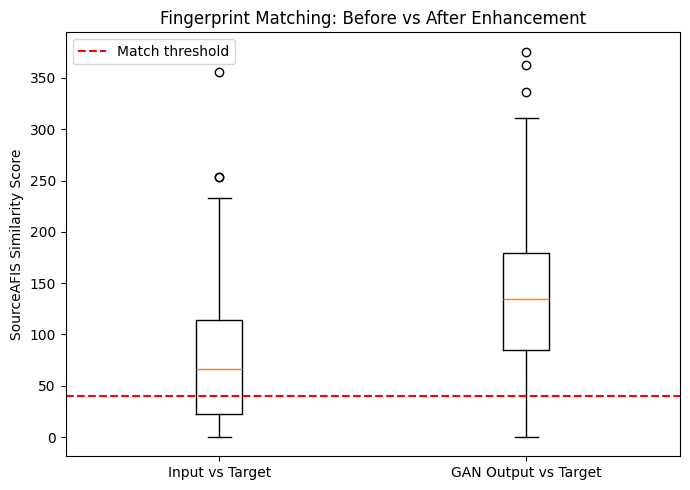

In [13]:
import numpy as np
import matplotlib.pyplot as plt

a, b = np.array(scores_input_vs_target), np.array(scores_gen_vs_target)
print(f"Input vs Target — mean {a.mean():.2f}, median {np.median(a):.2f}")
print(f"GAN vs Target   — mean {b.mean():.2f}, median {np.median(b):.2f}")
print(f"Pass rate @ {MATCH_THRESHOLD}: input {100*(a>=MATCH_THRESHOLD).mean():.1f}% | gen {100*(b>=MATCH_THRESHOLD).mean():.1f}%")

plt.figure(figsize=(7,5))
plt.boxplot([a, b], tick_labels=["Input vs Target", "GAN Output vs Target"])
plt.axhline(MATCH_THRESHOLD, color="red", linestyle="--", label="Match threshold")
plt.ylabel("SourceAFIS Similarity Score")
plt.title("Fingerprint Matching: Before vs After Enhancement")
plt.legend(); plt.tight_layout(); plt.show()

## Yolo Based Localization

In [14]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 69.0 MB/s eta 0:00:00


In [18]:
import numpy as np
from skimage.morphology import skeletonize
from skimage.filters import threshold_otsu

def extract_minutiae_points(gray_img, border_margin=15, min_dist=8):
    thresh = threshold_otsu(gray_img)
    binary = gray_img < thresh          # ridges assumed darker than background
    skeleton = skeletonize(binary)
    h, w = skeleton.shape

    ys, xs = np.nonzero(skeleton)
    points = []
    for y, x in zip(ys, xs):
        if y < border_margin or y >= h - border_margin or x < border_margin or x >= w - border_margin:
            continue
        nb = [skeleton[y-1,x], skeleton[y-1,x+1], skeleton[y,x+1], skeleton[y+1,x+1],
              skeleton[y+1,x], skeleton[y+1,x-1], skeleton[y,x-1], skeleton[y-1,x-1]]
        nb = [int(n) for n in nb]
        cn = sum(abs(nb[i] - nb[(i+1) % 8]) for i in range(8)) // 2
        if cn == 1:
            points.append((x, y, "ending"))
        elif cn == 3:
            points.append((x, y, "bifurcation"))

    filtered = []
    for x, y, t in points:
        if all((x-fx)**2 + (y-fy)**2 > min_dist**2 for fx, fy, _ in filtered):
            filtered.append((x, y, t))
    return filtered

In [19]:
YOLO_ROOT = Path("/content/drive/MyDrive/yolo_minutiae")
for sub in ["images/train", "images/val", "labels/train", "labels/val"]:
    (YOLO_ROOT / sub).mkdir(parents=True, exist_ok=True)

BOX_SIZE = 16
N_IMAGES = 150       # keep it light — subset, not full dataset
VAL_FRACTION = 0.15

target_files = sorted(TARGET_DIR.rglob("*.png"))[:N_IMAGES]
n_val = int(len(target_files) * VAL_FRACTION)

for i, fpath in enumerate(target_files):
    img = Image.open(fpath).convert("L").resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img)
    pts = extract_minutiae_points(arr)

    split = "val" if i < n_val else "train"
    img.save(YOLO_ROOT / f"images/{split}" / fpath.name)

    lines = []
    for x, y, t in pts:
        cls = 0 if t == "ending" else 1
        xc, yc, bw, bh = x/IMG_SIZE, y/IMG_SIZE, BOX_SIZE/IMG_SIZE, BOX_SIZE/IMG_SIZE
        lines.append(f"{cls} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")
    (YOLO_ROOT / f"labels/{split}" / (fpath.stem + ".txt")).write_text("\n".join(lines))

print("Train:", len(list((YOLO_ROOT/'images/train').glob('*.png'))))
print("Val:", len(list((YOLO_ROOT/'images/val').glob('*.png'))))

Train: 128
Val: 22


In [20]:
(YOLO_ROOT / "data.yaml").write_text(f"""
path: {YOLO_ROOT}
train: images/train
val: images/val
names:
  0: ridge_ending
  1: bifurcation
""")

122

In [21]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
model.train(
    data=str(YOLO_ROOT / "data.yaml"),
    epochs=20,
    imgsz=256,
    batch=16,
    project="/content/drive/MyDrive/GAFIS_yolo",   # saved to Drive this time
    name="minutiae_run1",
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.105 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/yolo_minutiae/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b115823c7a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

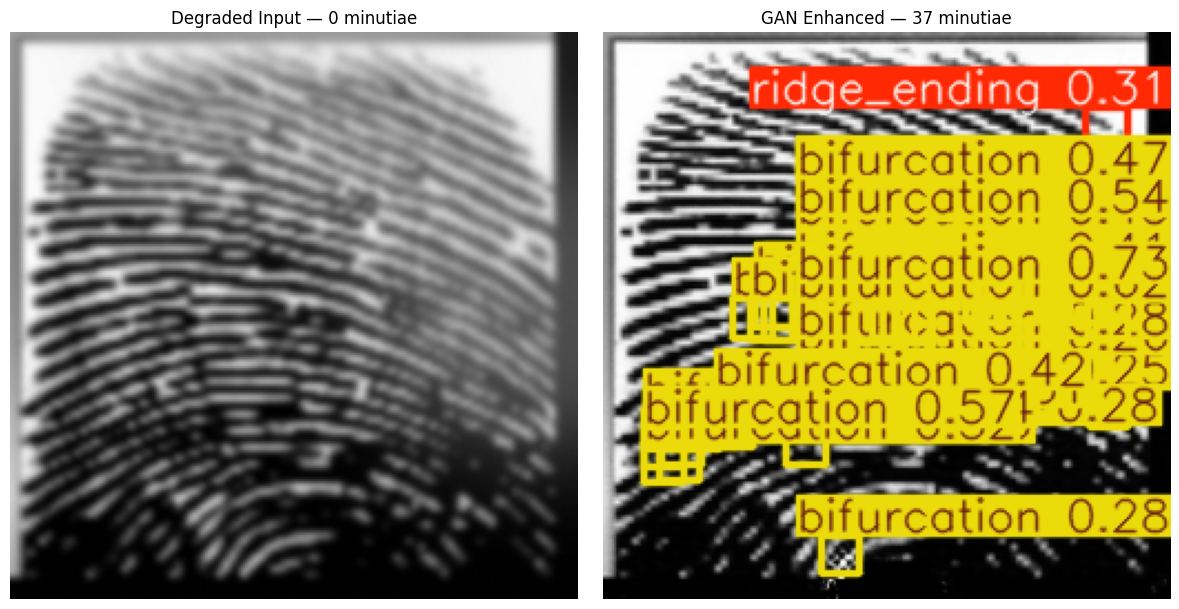

In [22]:
best_weights = "/content/drive/MyDrive/GAFIS_yolo/minutiae_run1/weights/best.pt"
detector = YOLO(best_weights)

inp, tgt = next(iter(val_loader))
inp, tgt = inp.to(device), tgt.to(device)
with torch.no_grad():
    fake = generator(inp)

def tensor_to_uint8(t):
    return ((t.squeeze().cpu().numpy() + 1) / 2 * 255).clip(0, 255).astype("uint8")

idx = 0
res_inp = detector(tensor_to_uint8(inp[idx]), verbose=False)[0]
res_gen = detector(tensor_to_uint8(fake[idx]), verbose=False)[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(res_inp.plot()); axes[0].set_title(f"Degraded Input — {len(res_inp.boxes)} minutiae"); axes[0].axis("off")
axes[1].imshow(res_gen.plot()); axes[1].set_title(f"GAN Enhanced — {len(res_gen.boxes)} minutiae"); axes[1].axis("off")
plt.tight_layout(); plt.show()

Minutiae counting:   0%|          | 0/75 [00:00<?, ?it/s]

Avg minutiae — input: 0.6 | GAN: 24.5
Median minutiae — input: 0.0 | GAN: 21.0


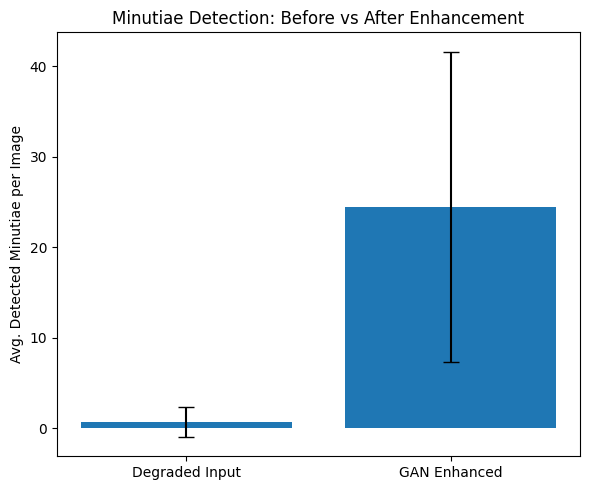

In [23]:
minutiae_counts_input, minutiae_counts_gen = [], []

with torch.no_grad():
    for inp, tgt in tqdm(val_loader, desc="Minutiae counting"):
        inp = inp.to(device)
        fake = generator(inp)
        for i in range(inp.size(0)):
            n_in = len(detector(tensor_to_uint8(inp[i]), verbose=False)[0].boxes)
            n_gen = len(detector(tensor_to_uint8(fake[i]), verbose=False)[0].boxes)
            minutiae_counts_input.append(n_in)
            minutiae_counts_gen.append(n_gen)

minutiae_counts_input = np.array(minutiae_counts_input)
minutiae_counts_gen = np.array(minutiae_counts_gen)

print(f"Avg minutiae — input: {minutiae_counts_input.mean():.1f} | GAN: {minutiae_counts_gen.mean():.1f}")
print(f"Median minutiae — input: {np.median(minutiae_counts_input):.1f} | GAN: {np.median(minutiae_counts_gen):.1f}")

plt.figure(figsize=(6,5))
plt.bar(["Degraded Input", "GAN Enhanced"],
        [minutiae_counts_input.mean(), minutiae_counts_gen.mean()],
        yerr=[minutiae_counts_input.std(), minutiae_counts_gen.std()], capsize=6)
plt.ylabel("Avg. Detected Minutiae per Image")
plt.title("Minutiae Detection: Before vs After Enhancement")
plt.tight_layout(); plt.show()

In [25]:
scores_gen_arr = np.array(scores_gen_vs_target)

Impostor matching:   0%|          | 0/300 [00:00<?, ?it/s]

/tmp/ipykernel_708/3746928580.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(img, mode="L").save(buf, format="PNG")


Impostor scores — mean 1.95, n=300


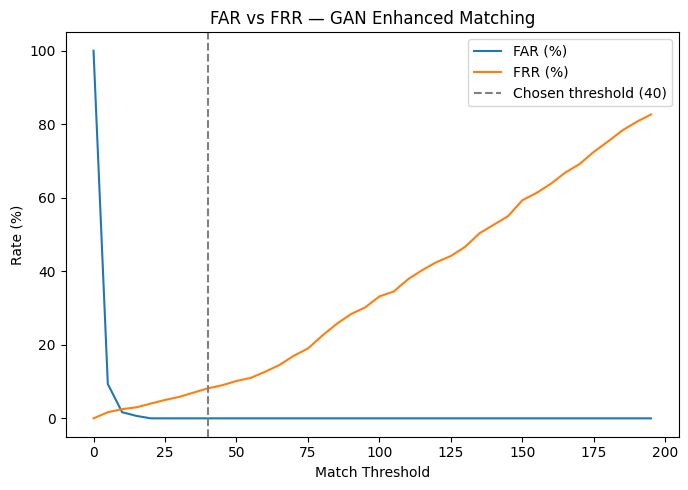

At threshold=40 — FAR: 0.00%  FRR: 8.17%


In [26]:
import random

N_IMPOSTOR_PAIRS = 300
random.seed(42)

val_targets = [tgt for _, tgt in val_loader.dataset]  # careful: only if val_ds is small enough to hold in memory
# safer: iterate val_loader once and cache tensors
cached = [(inp.clone(), tgt.clone()) for inp, tgt in val_ds]

impostor_scores = []
for _ in tqdm(range(N_IMPOSTOR_PAIRS), desc="Impostor matching"):
    i, j = random.sample(range(len(cached)), 2)
    probe_inp, _ = cached[i]
    with torch.no_grad():
        probe_gen = generator(probe_inp.unsqueeze(0).to(device))[0]
    _, cand_tgt = cached[j]

    gen_t = build_template(probe_gen)
    tgt_t = build_template(cand_tgt.to(device))
    s = match_score(gen_t, tgt_t)
    if s is not None:
        impostor_scores.append(s)

impostor_scores = np.array(impostor_scores)
print(f"Impostor scores — mean {impostor_scores.mean():.2f}, n={len(impostor_scores)}")

thresholds = np.arange(0, 200, 5)
far = [(impostor_scores >= t).mean() * 100 for t in thresholds]
frr = [(scores_gen_arr < t).mean() * 100 for t in thresholds]

plt.figure(figsize=(7,5))
plt.plot(thresholds, far, label="FAR (%)")
plt.plot(thresholds, frr, label="FRR (%)")
plt.axvline(MATCH_THRESHOLD, color="gray", linestyle="--", label="Chosen threshold (40)")
plt.xlabel("Match Threshold"); plt.ylabel("Rate (%)")
plt.title("FAR vs FRR — GAN Enhanced Matching")
plt.legend(); plt.tight_layout(); plt.show()

t40_far = (impostor_scores >= 40).mean() * 100
t40_frr = (scores_gen_arr < 40).mean() * 100
print(f"At threshold=40 — FAR: {t40_far:.2f}%  FRR: {t40_frr:.2f}%")

/tmp/ipykernel_708/3746928580.py:16: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(img, mode="L").save(buf, format="PNG")


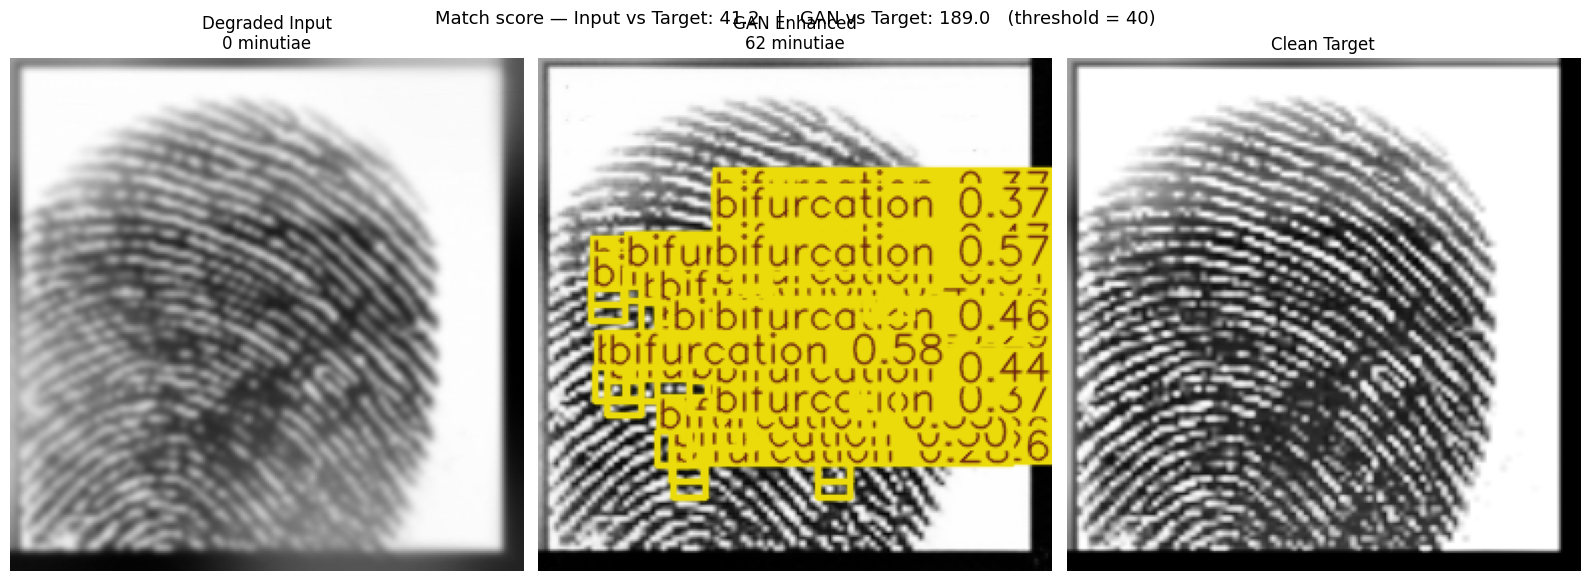

Sample index: 388
Minutiae detected — input: 0, GAN-enhanced: 62
Match score — input vs target: 41.24
Match score — GAN vs target: 188.96
Passes threshold (40)? input: True | GAN: True


In [27]:
# Pick one sample from the validation set (change the seed/index to try different fingerprints)
sample_idx = random.randint(0, len(val_ds) - 1)
inp_t, tgt_t = val_ds[sample_idx]
inp_t, tgt_t = inp_t.unsqueeze(0).to(device), tgt_t.unsqueeze(0).to(device)

with torch.no_grad():
    fake_t = generator(inp_t)

# --- Minutiae detection (YOLOv8) ---
res_inp = detector(tensor_to_uint8(inp_t[0]), verbose=False)[0]
res_gen = detector(tensor_to_uint8(fake_t[0]), verbose=False)[0]

# --- SourceAFIS matching ---
inp_tmpl = build_template(inp_t[0])
gen_tmpl = build_template(fake_t[0])
tgt_tmpl = build_template(tgt_t[0])

score_input_vs_target = match_score(inp_tmpl, tgt_tmpl)
score_gen_vs_target = match_score(gen_tmpl, tgt_tmpl)

# --- Combined visualization ---
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].imshow(res_inp.plot())
axes[0].set_title(f"Degraded Input\n{len(res_inp.boxes)} minutiae")
axes[0].axis("off")

axes[1].imshow(res_gen.plot())
axes[1].set_title(f"GAN Enhanced\n{len(res_gen.boxes)} minutiae")
axes[1].axis("off")

axes[2].imshow(tensor_to_uint8(tgt_t[0]), cmap="gray")
axes[2].set_title("Clean Target")
axes[2].axis("off")

plt.suptitle(
    f"Match score — Input vs Target: {score_input_vs_target:.1f}   |   "
    f"GAN vs Target: {score_gen_vs_target:.1f}   (threshold = {MATCH_THRESHOLD})",
    fontsize=13
)
plt.tight_layout()
plt.show()

print(f"Sample index: {sample_idx}")
print(f"Minutiae detected — input: {len(res_inp.boxes)}, GAN-enhanced: {len(res_gen.boxes)}")
print(f"Match score — input vs target: {score_input_vs_target:.2f}")
print(f"Match score — GAN vs target: {score_gen_vs_target:.2f}")
print(f"Passes threshold ({MATCH_THRESHOLD})? input: {score_input_vs_target >= MATCH_THRESHOLD} | GAN: {score_gen_vs_target >= MATCH_THRESHOLD}")